# Notebook 1: Data Understanding and Fraud Pattern Analysis

**Project**: E-Commerce Fraud Detection Analysis  
**Subject**: Fraud Detection Analysis (MBA Data Science)  
**Dataset**: IEEE-CIS Fraud Detection Dataset  

---

## 1. Project Objective & Workflow

The primary objective of this notebook is to perform an empirical **Exploratory Fraud Analysis** on the IEEE-CIS Fraud Detection dataset to answer the central research question:
> **What characteristics and patterns are associated with fraudulent transactions?**


In [1]:
# Imports, Setup & Self-Contained Functions
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = 'data/raw'
fig_dir = 'outputs/figures'
tbl_dir = 'outputs/tables'

os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tbl_dir, exist_ok=True)

def reduce_mem_usage(df, verbose=False):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if pd.api.types.is_integer_dtype(df[col]):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min >= np.iinfo(np.int64).min and c_max <= np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    if verbose:
        end_mem = df.memory_usage().sum() / 1024**2
        print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

def load_and_merge_data(data_dir, nrows=None):
    trans_path = os.path.join(data_dir, 'train_transaction.csv')
    id_path = os.path.join(data_dir, 'train_identity.csv')
    print('Loading train_transaction.csv...', flush=True)
    trans_df = pd.read_csv(trans_path, nrows=nrows)
    print('Loading train_identity.csv...', flush=True)
    id_df = pd.read_csv(id_path, nrows=nrows)
    print(f'Left joining transaction ({len(trans_df):,} rows) and identity ({len(id_df):,} rows)...', flush=True)
    merged_df = pd.merge(trans_df, id_df, on='TransactionID', how='left')
    merged_df = reduce_mem_usage(merged_df, verbose=True)
    print(f'Merged dataset shape: {merged_df.shape}')
    return merged_df

def assess_data_quality(df):
    n_rows, n_cols = df.shape
    n_duplicates = df['TransactionID'].duplicated().sum()
    target_dist = df['isFraud'].value_counts().to_dict()
    legit_count = target_dist.get(0, 0)
    fraud_count = target_dist.get(1, 0)
    fraud_pct = (fraud_count / n_rows) * 100
    imbalance_ratio = legit_count / max(1, fraud_count)
    missing_summary = df.isnull().sum()
    cols_with_missing = (missing_summary > 0).sum()
    top_missing = (missing_summary / n_rows * 100).nlargest(10).to_dict()
    return {
        'n_rows': n_rows, 'n_cols': n_cols, 'n_duplicates': int(n_duplicates),
        'legitimate_count': int(legit_count), 'fraud_count': int(fraud_count),
        'fraud_percentage': round(float(fraud_pct), 4),
        'imbalance_ratio': round(float(imbalance_ratio), 2),
        'cols_with_missing': int(cols_with_missing),
        'top_missing_pct': top_missing
    }

def calculate_categorical_fraud_rates(df, col_name, top_n=10):
    df_sub = df[[col_name, 'isFraud']].copy()
    df_sub[col_name] = df_sub[col_name].fillna('Missing')
    grouped = df_sub.groupby(col_name).agg(
        Total_Transactions=('isFraud', 'count'),
        Fraudulent_Transactions=('isFraud', 'sum')
    ).reset_index()
    grouped['Fraud_Rate_Pct'] = (grouped['Fraudulent_Transactions'] / grouped['Total_Transactions'] * 100).round(2)
    grouped = grouped.sort_values(by='Total_Transactions', ascending=False).head(top_n)
    grouped = grouped.rename(columns={col_name: 'Category'})
    grouped.insert(0, 'Feature', col_name)
    return grouped

df = load_and_merge_data(data_dir)


Loading train_transaction.csv...
Loading train_identity.csv...
Left joining transaction (590,540 rows) and identity (144,233 rows)...
Memory usage decreased to 1073.53 MB (45.9% reduction)
Merged dataset shape: (590540, 434)


## 2. Dataset Overview & Data Quality Audit


In [2]:
# Assess Data Quality & Audit Metrics
quality_summary = assess_data_quality(df)

print('=== DATASET DATA QUALITY AUDIT ===')
print(f"Total Merged Transactions (Rows): {quality_summary['n_rows']:,}")
print(f"Total Features (Columns):         {quality_summary['n_cols']}")
print(f"Duplicate Transactions:           {quality_summary['n_duplicates']}")
print(f"Legitimate Transactions (Class 0): {quality_summary['legitimate_count']:,} ({100 - quality_summary['fraud_percentage']:.4f}%)")
print(f"Fraudulent Transactions (Class 1): {quality_summary['fraud_count']:,} ({quality_summary['fraud_percentage']:.4f}%)")
print(f"Class Imbalance Ratio:            {quality_summary['imbalance_ratio']}:1")

dataset_summary_df = pd.DataFrame([{
    'Metric': 'Total Merged Rows', 'Value': f"{quality_summary['n_rows']:,}"
}, {
    'Metric': 'Total Columns', 'Value': f"{quality_summary['n_cols']}"
}, {
    'Metric': 'Legitimate Transactions (isFraud=0)', 'Value': f"{quality_summary['legitimate_count']:,}"
}, {
    'Metric': 'Fraudulent Transactions (isFraud=1)', 'Value': f"{quality_summary['fraud_count']:,}"
}, {
    'Metric': 'Fraud Percentage (%)', 'Value': f"{quality_summary['fraud_percentage']:.4f}%"
}, {
    'Metric': 'Imbalance Ratio', 'Value': f"{quality_summary['imbalance_ratio']}:1"
}])
dataset_summary_df.to_csv(os.path.join(tbl_dir, 'dataset_summary.csv'), index=False)
print(dataset_summary_df)


=== DATASET DATA QUALITY AUDIT ===
Total Merged Transactions (Rows): 590,540
Total Features (Columns):         434
Duplicate Transactions:           0
Legitimate Transactions (Class 0): 569,877 (96.5010%)
Fraudulent Transactions (Class 1): 20,663 (3.4990%)
Class Imbalance Ratio:            27.58:1
                                Metric    Value
0                    Total Merged Rows  590,540
1                        Total Columns      434
2  Legitimate Transactions (isFraud=0)  569,877
3  Fraudulent Transactions (isFraud=1)   20,663
4                 Fraud Percentage (%)  3.4990%
5                      Imbalance Ratio  27.58:1


## 3. Target Distribution & Missing Values Plot


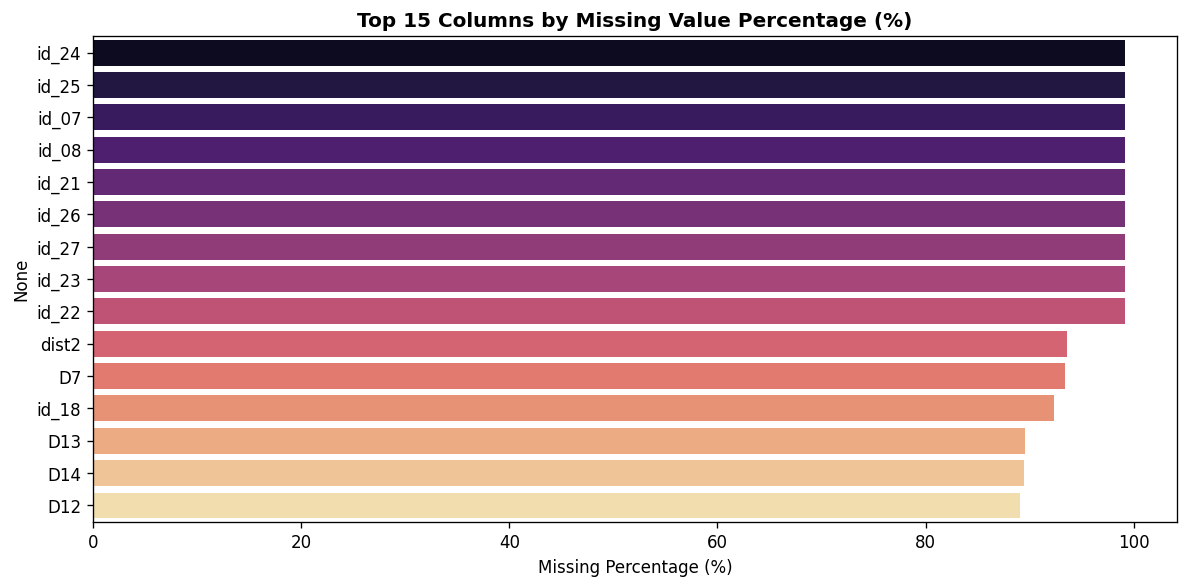

In [3]:
# Missing Value Plot
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
top_missing = missing_pct.head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_missing.values, y=top_missing.index, palette='magma')
plt.title('Top 15 Columns by Missing Value Percentage (%)', fontsize=12, fontweight='bold')
plt.xlabel('Missing Percentage (%)')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'missing_value_analysis.png'), dpi=300)
plt.show()


## 4. Transaction Amount & Time Analysis


=== FRAUD RATE BY TRANSACTION AMOUNT BANDS ===
         amt_band  Total_Transactions  Fraud_Transactions  Fraud_Rate_Pct
0   Q1 (Very Low)              121161                5302            4.38
1        Q2 (Low)              124763                3259            2.61
2     Q3 (Medium)              122695                4060            3.31
3       Q4 (High)              104478                2817            2.70
4  Q5 (Very High)              117443                5225            4.45


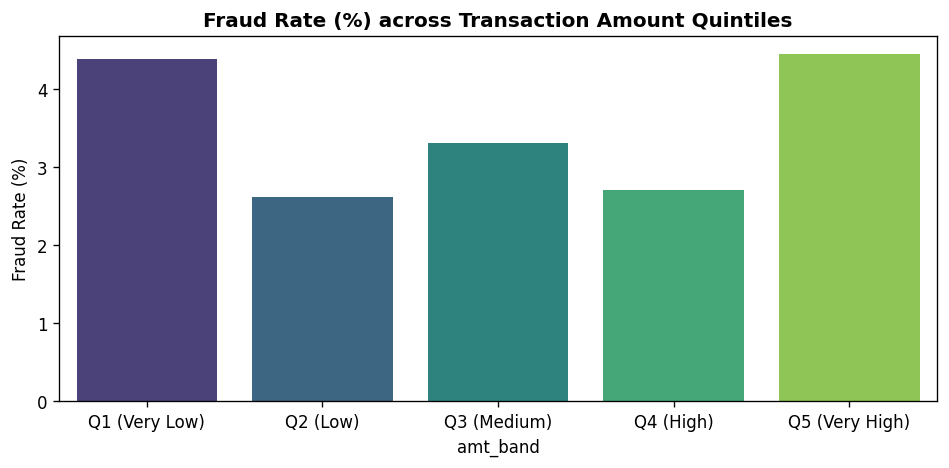

In [4]:
# Transaction Amount Fraud Analysis
df['amt_band'] = pd.qcut(df['TransactionAmt'], q=5, labels=['Q1 (Very Low)', 'Q2 (Low)', 'Q3 (Medium)', 'Q4 (High)', 'Q5 (Very High)'])
amt_summary = df.groupby('amt_band').agg(
    Total_Transactions=('isFraud', 'count'),
    Fraud_Transactions=('isFraud', 'sum')
).reset_index()
amt_summary['Fraud_Rate_Pct'] = (amt_summary['Fraud_Transactions'] / amt_summary['Total_Transactions'] * 100).round(2)
amt_summary.to_csv(os.path.join(tbl_dir, 'fraud_rate_amt_bands.csv'), index=False)
print('=== FRAUD RATE BY TRANSACTION AMOUNT BANDS ===')
print(amt_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=amt_summary, x='amt_band', y='Fraud_Rate_Pct', palette='viridis')
plt.title('Fraud Rate (%) across Transaction Amount Quintiles', fontsize=12, fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'transaction_amount_fraud.png'), dpi=300)
plt.show()
